In [7]:
!pip install kagglehub

In [8]:
import kagglehub

path = kagglehub.dataset_download("udcdse/aquaponics-dataset")

print(path)

Using Colab cache for faster access to the 'aquaponics-dataset' dataset.
/kaggle/input/aquaponics-dataset


In [9]:
import os

os.listdir(path)

['DO2 ACTSOR-AQUA-UDC-1.json',
 'Ammonium ACTSOR-AQUA-UDC-1.json',
 'Salinity ACTSOR-AQUA-UDC-4.json',
 'Nitrite ACTSOR-AQUA-UDC-1.json',
 'ph ACTSOR-AQUA-UDC-3.json',
 'Ammonium ACTSOR-AQUA-UDC-3.json',
 'ph ACTSOR-AQUA-UDC-1.json',
 'Ammonium ACTSOR-AQUA-UDC-2.json',
 'ph ACTSOR-AQUA-UDC-2.json']

In [18]:
import os
import pandas as pd
import json

files = os.listdir(path)

data_list = []

for file in files:
    if file.endswith(".json"):
        with open(os.path.join(path, file)) as f:
            data = json.load(f)
            df_temp = pd.json_normalize(data)
            df_temp['source_file'] = file
            data_list.append(df_temp)

df = pd.concat(data_list, ignore_index=True)

df.head()

,ballName,readTime,do2,source_file,ammonium,salinity,nitrite,ph
0,ACTSOR-AQUA-UDC-1,1487656862397,7.905,DO2 ACTSOR-AQUA-UDC-1.json,NaN,NaN,NaN,NaN
1,ACTSOR-AQUA-UDC-1,1487656867517,7.912,DO2 ACTSOR-AQUA-UDC-1.json,NaN,NaN,NaN,NaN
2,ACTSOR-AQUA-UDC-1,1487656872617,7.905,DO2 ACTSOR-AQUA-UDC-1.json,NaN,NaN,NaN,NaN
3,ACTSOR-AQUA-UDC-1,1487656877717,7.905,DO2 ACTSOR-AQUA-UDC-1.json,NaN,NaN,NaN,NaN
4,ACTSOR-AQUA-UDC-1,1487656882897,7.899,DO2 ACTSOR-AQUA-UDC-1.json,NaN,NaN,NaN,NaN


In [19]:
print(df.columns)
df.info()

Index(['ballName', 'readTime', 'do2', 'source_file', 'ammonium', 'salinity',
       'nitrite', 'ph'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61875 entries, 0 to 61874
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ballName     61875 non-null  object
 1   readTime     61875 non-null  object
 2   do2          8409 non-null   object
 3   source_file  61875 non-null  object
 4   ammonium     22918 non-null  object
 5   salinity     1107 non-null   object
 6   nitrite      8376 non-null   object
 7   ph           21065 non-null  object
dtypes: object(8)
memory usage: 3.8+ MB


In [20]:
df['sensor'] = df['source_file'].str.split().str[0]

In [21]:
df['value'] = df[['do2', 'ammonium', 'salinity', 'nitrite', 'ph']].bfill(axis=1).iloc[:,0]

In [24]:
df['value'] = pd.to_numeric(df['value'], errors='coerce')

In [25]:
df_clean = df[['readTime', 'sensor', 'value']]
df_clean.head()

,readTime,sensor,value
0,1487656862397,DO2,7.905
1,1487656867517,DO2,7.912
2,1487656872617,DO2,7.905
3,1487656877717,DO2,7.905
4,1487656882897,DO2,7.899


In [27]:
df_pivot = df_clean.pivot_table(
    index='readTime',
    columns='sensor',
    values='value'
).reset_index()

df_pivot.head()

sensor,readTime,Ammonium,DO2,Nitrite,Salinity,ph
0,1485421966960,4.8,NaN,NaN,NaN,NaN
1,1485421972020,4.8,NaN,NaN,NaN,NaN
2,1485421977191,4.9,NaN,NaN,NaN,NaN
3,1485421982350,4.8,NaN,NaN,NaN,NaN
4,1485421987433,4.8,NaN,NaN,NaN,NaN


In [28]:
df_pivot['readTime'] = pd.to_datetime(df_pivot['readTime'], unit='ms')

/tmp/ipykernel_3503/1762794095.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df_pivot['readTime'] = pd.to_datetime(df_pivot['readTime'], unit='ms')


In [29]:
df_pivot = df_pivot.fillna(method='ffill')

/tmp/ipykernel_3503/1853478003.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pivot = df_pivot.fillna(method='ffill')


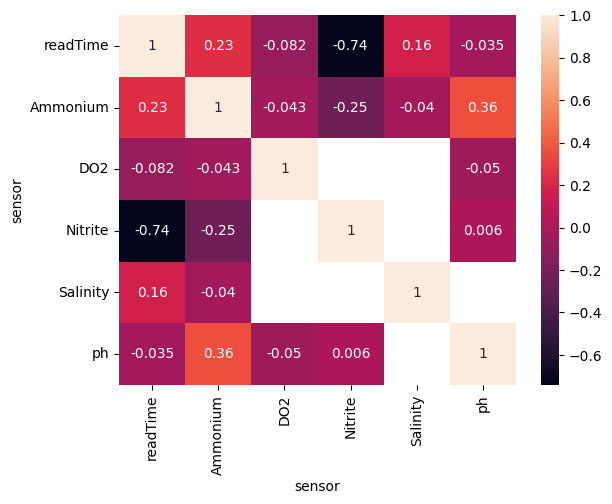

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_pivot.corr(), annot=True)
plt.show()

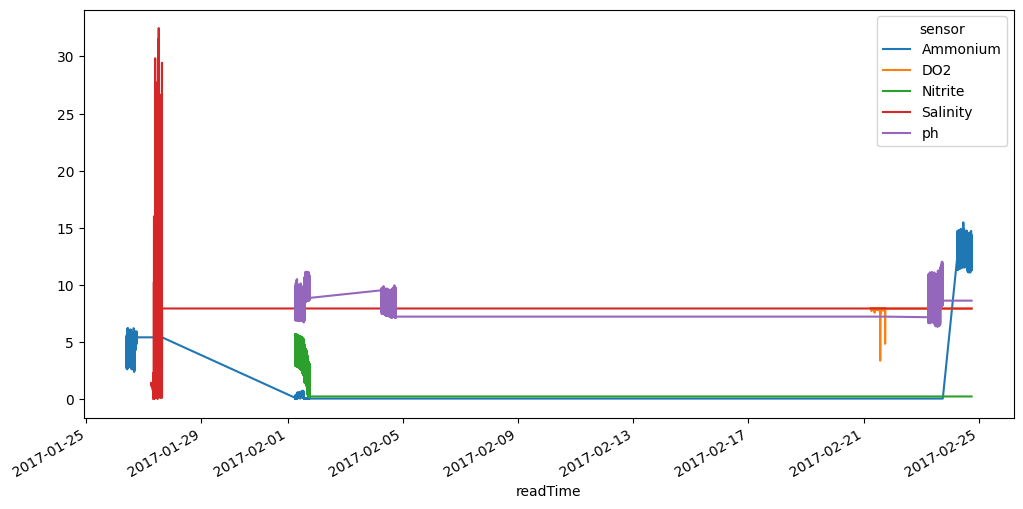

In [31]:
df_pivot.plot(x='readTime', figsize=(12,6))
plt.show()

In [32]:
df_pivot.describe()

sensor,readTime,Ammonium,DO2,Nitrite,Salinity,ph
count,45123,45123.000000,25195.000000,37877.000000,38984.000000,37877.000000
mean,2017-02-12 22:49:22.239640832,3.195491,7.908297,0.919338,7.834904,8.007223
min,2017-01-26 09:12:46.960000,0.000000,3.358000,0.148000,0.000000,6.332000
25%,2017-02-01 11:45:10.918500096,0.036000,7.905000,0.222000,7.926000,7.215000
50%,2017-02-21 09:45:24.816999936,0.036000,7.905000,0.222000,7.926000,7.791000
75%,2017-02-23 13:53:14.264000,5.400000,7.905000,0.222000,7.926000,8.613000
max,2017-02-24 17:58:59.562000,15.472000,7.957000,5.669000,32.485000,12.015000
std,NaN,4.871684,0.053988,1.415931,1.075774,0.895011
